# Volume Analysis: `recon_vol_05.h5`
This notebook loads the HDF5 file containing a reconstructed volume, inspects its contents, and visualizes representative slices and projections.

## What you'll find here
1. Inspect HDF5 structure (groups / datasets, shapes, dtypes)
2. Automatically pick a 3D volume dataset (or let you choose)
3. Basic stats (min / max / mean / std, optional percentiles)
4. Central orthogonal slices (XY, XZ, YZ)
5. Interactive slice explorer (slider + axis selector) if `ipywidgets` available
6. Histograms & intensity clipping helper
7. Maximum Intensity Projections (MIPs)
8. (Optional) Surface / isosurface preview if `scikit-image` available

Feel free to skip cells or adapt the logic for downstream tasks.

In [12]:
# Imports
import os, sys, math, textwrap
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

# Try optional libs
try:
    import ipywidgets as widgets
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False

try:
    from skimage import measure
    from skimage.metrics import structural_similarity as ssim_metric
    _HAVE_SKIMAGE = True
    _HAVE_SSIM = True
except Exception:
    try:
        from skimage.metrics import structural_similarity as ssim_metric
        _HAVE_SKIMAGE = False
        _HAVE_SSIM = True
    except Exception:
        _HAVE_SKIMAGE = False
        _HAVE_SSIM = False

DATA_DIR = Path('..') / 'data'  # relative to notebooks folder
H5_FILENAME = 'recon_vol_05.h5'            # Ground truth / reference volume
H5_FILENAME_RECONS = 'recon_vol_05_recon.h5'  # <-- Set this to your reconstructed volume filename
H5_FILENAME_RECONS = H5_FILENAME
H5_PATH = (DATA_DIR / H5_FILENAME).resolve()
H5_PATH_RECONS = (DATA_DIR / H5_FILENAME_RECONS).resolve()
print('Using reference file:', H5_PATH)
print('Using reconstructed file (expected):', H5_PATH_RECONS)
assert H5_PATH.exists(), f'HDF5 reference file not found: {H5_PATH}'
if not H5_PATH_RECONS.exists():
    print('WARNING: Reconstructed file does not exist yet:', H5_PATH_RECONS)


Using reference file: /Users/lfbarba/GitHub/deep-anomaly-detection/data/recon_vol_05.h5
Using reconstructed file (expected): /Users/lfbarba/GitHub/deep-anomaly-detection/data/recon_vol_05.h5


In [13]:
# Utility: recursively list datasets with shape & dtype
def list_h5_datasets(h5_obj):
    out = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            out.append((name, obj.shape, obj.dtype))
    h5_obj.visititems(visitor)
    return out

with h5py.File(H5_PATH, 'r') as f:
    datasets = list_h5_datasets(f)

print(f'Found {len(datasets)} dataset(s):')
for name, shape, dtype in datasets:
    print(f'  - {name}: shape={shape}, dtype={dtype}')

# Heuristic: pick first 3D dataset (or 4D with leading singleton)
candidate = None
for name, shape, dtype in datasets:
    if len(shape) == 3:
        candidate = name
        break
    if len(shape) == 4 and shape[0] in (1,):
        candidate = name
        break
print('Auto-selected dataset:' , candidate)
if candidate is None:
    raise ValueError('No suitable 3D dataset found automatically. Please inspect and select manually.')
SELECTED_DATASET = candidate

Found 1 dataset(s):
  - recon: shape=(1800, 2016, 2016), dtype=float32
Auto-selected dataset: recon


### Large Volume Handling Strategy
The volume size (e.g. 1800 x 2016 x 2016 ≈ 7.3B voxels, potentially >14 GB if float32) is too large to load wholly into RAM.

Approach used below:
- Do NOT load full array unless explicitly forced.
- Stats: sample a limited number of *whole Z slices* (contiguous reads) to approximate global statistics.
- Central orthogonal slices: read only the needed planes.
- Histogram: reuse sampled slices.
- MIPs: computed by streaming passes over the dataset (no full load). Each projection is built in-place.
- Interactive viewer: reads individual slices on demand from disk.
- Isosurface: skipped unless forced (requires full load or heavy subsampling).

You can tune parameters like `FORCE_FULL_LOAD`, `STATS_MAX_SLICES`, and `SLICE_SAMPLE_TARGET_VOXELS` for accuracy vs. speed.

### Load dataset lazily and compute basic stats
We avoid loading the full array into memory until necessary. Slices are read on-demand; stats may require reading entirely (can be optimized with sampling if very large).

In [14]:
# Load dataset reference and compute approximate stats via slice sampling (no full volume load)
FORCE_FULL_LOAD = False  # Set True ONLY if memory allows full load
STATS_MAX_SLICES = 32    # Max number of Z slices to sample for stats/hist
SLICE_SAMPLE_TARGET_VOXELS = 12_000_000  # Upper bound of voxels for stats/hist

with h5py.File(H5_PATH, 'r') as f:
    dset = f[SELECTED_DATASET]
    shape = dset.shape
    dtype = dset.dtype
    nz, ny, nx = shape
    total_voxels = math.prod(shape)
    print('Dataset:', SELECTED_DATASET)
    print('Shape:', shape, 'dtype:', dtype, 'total voxels:', total_voxels)

    if FORCE_FULL_LOAD:
        print('FORCE_FULL_LOAD=True -> loading entire volume (may exhaust memory).')
        vol = dset[()]
        loaded_fully = True
        sample_slices = None
        data_for_stats = vol.ravel()
    else:
        loaded_fully = False
        # Decide number of slices to sample based on voxel target
        max_slices_by_target = max(1, SLICE_SAMPLE_TARGET_VOXELS // (ny * nx))
        n_sample = min(STATS_MAX_SLICES, max_slices_by_target, nz)
        # Evenly spaced slice indices
        sample_slices = np.linspace(0, nz-1, n_sample, dtype=int)
        print(f'Sampling {n_sample} Z slices for stats/hist: {sample_slices[:6]}...')
        # Read sampled slices (contiguous reads per slice)
        sampled = np.empty((n_sample, ny, nx), dtype=dset.dtype)
        for i, z in enumerate(sample_slices):
            sampled[i] = dset[z, :, :]
        data_for_stats = sampled.ravel()
        vol = None  # not loaded

stats = {
    'min': float(np.min(data_for_stats)),
    'max': float(np.max(data_for_stats)),
    'mean': float(np.mean(data_for_stats)),
    'std': float(np.std(data_for_stats)),
    'p1': float(np.percentile(data_for_stats, 1)),
    'p50': float(np.percentile(data_for_stats, 50)),
    'p99': float(np.percentile(data_for_stats, 99)),
}
print('Loaded fully:', loaded_fully)
print('Stats (sampled)' if not loaded_fully else 'Stats', stats)
if not loaded_fully:
    print('Note: statistics & histogram derived from sampled slices, not full volume.')
if loaded_fully:
    print('Volume array in memory: vol')

Dataset: recon
Shape: (1800, 2016, 2016) dtype: float32 total voxels: 7315660800
Sampling 2 Z slices for stats/hist: [   0 1799]...


OSError: Can't synchronously read data (can't open directory (/usr/local/hdf5/lib/plugin). Please verify its existence)

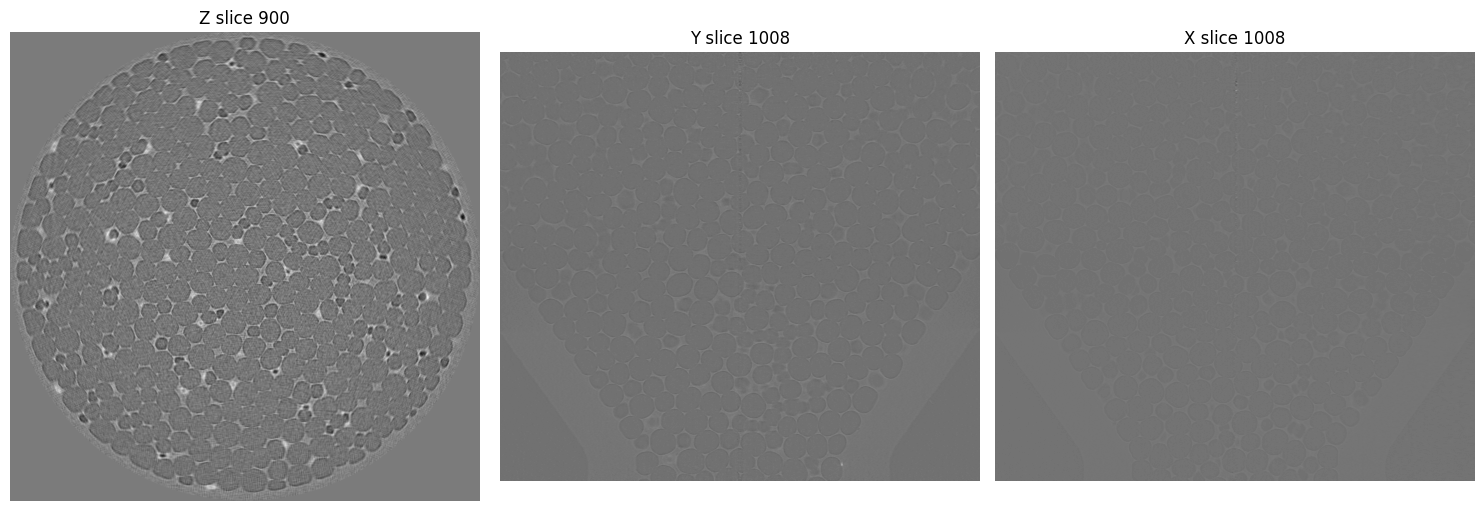

In [15]:
# Display central orthogonal slices without loading full volume
with h5py.File(H5_PATH, 'r') as f:
    dset = f[SELECTED_DATASET]
    nz, ny, nx = dset.shape
    cz, cy, cx = nz//2, ny//2, nx//2
    slice_z = dset[cz, :, :]
    slice_y = dset[:, cy, :]  # This reads all z for a single y -> could be large; consider stride
    slice_x = dset[:, :, cx]

# Optionally downsample Y and X orthogonal slices for display if memory/time is large
DOWNSAMPLE_FACT = 1  # set >1 to subsample axes for huge slices
if DOWNSAMPLE_FACT > 1:
    slice_z = slice_z[::DOWNSAMPLE_FACT, ::DOWNSAMPLE_FACT]
    slice_y = slice_y[::DOWNSAMPLE_FACT, ::DOWNSAMPLE_FACT]
    slice_x = slice_x[::DOWNSAMPLE_FACT, ::DOWNSAMPLE_FACT]

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(slice_z, cmap='gray')
axes[0].set_title(f'Z slice {cz}')
axes[1].imshow(slice_y, cmap='gray')
axes[1].set_title(f'Y slice {cy}')
axes[2].imshow(slice_x, cmap='gray')
axes[2].set_title(f'X slice {cx}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Interactive slice explorer (lazy disk access if ipywidgets available)
if _HAVE_WIDGETS:
    import matplotlib.pyplot as plt
    from IPython.display import display, clear_output
    axis_dropdown = widgets.Dropdown(options=[('Z','z'), ('Y','y'), ('X','x')], value='z', description='Axis:')
    # Need shape; open file once for shape
    with h5py.File(H5_PATH, 'r') as f:
        nz, ny, nx = f[SELECTED_DATASET].shape
    slice_slider = widgets.IntSlider(value=nz//2, min=0, max=nz-1, step=1, description='Index:')

    # Use sampled stats for initial clim
    vmin_init, vmax_init = stats['p1'], stats['p99']
    clim_slider = widgets.FloatRangeSlider(value=[vmin_init, vmax_init], min=stats['min'], max=stats['max'], step=(stats['max']-stats['min'])/500 if stats['max']>stats['min'] else 1, description='CLim:')

    def update_max(axis_code):
        if axis_code=='z': return nz-1
        if axis_code=='y': return ny-1
        return nx-1

    def on_axis_change(change):
        slice_slider.max = update_max(change['new'])
        slice_slider.value = slice_slider.max//2
    axis_dropdown.observe(on_axis_change, names='value')

    out = widgets.Output()

    def fetch_slice(axc, idx):
        with h5py.File(H5_PATH, 'r') as f:
            d = f[SELECTED_DATASET]
            if axc=='z':
                return d[idx, :, :]
            elif axc=='y':
                return d[:, idx, :]
            else:
                return d[:, :, idx]

    def render(*args):
        with out:
            clear_output(wait=True)
            axc = axis_dropdown.value
            idx = slice_slider.value
            vmin, vmax = clim_slider.value
            img = fetch_slice(axc, idx)
            plt.figure(figsize=(5,5))
            plt.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
            plt.title(f'{axc.upper()} slice {idx}')
            plt.axis('off')
            plt.show()

    for w in (axis_dropdown, slice_slider, clim_slider):
        w.observe(lambda change: render(), names='value')
    render()
    display(widgets.VBox([widgets.HBox([axis_dropdown, slice_slider]), clim_slider, out]))
else:
    print('ipywidgets not available; skipping interactive explorer. Install with: pip install ipywidgets')

In [ ]:
# Histogram using sampled data (from slice sampling); can resample more slices if desired
if 'sample_slices' in globals() and sample_slices is not None:
    # Reconstruct sampled array again only if we didn't keep it; keep memory modest
    with h5py.File(H5_PATH, 'r') as f:
        dset = f[SELECTED_DATASET]
        nz, ny, nx = dset.shape
        n_sample = len(sample_slices)
        sampled = np.empty((n_sample, ny, nx), dtype=dset.dtype)
        for i, z in enumerate(sample_slices):
            sampled[i] = dset[z, :, :]
    data_for_hist = sampled.ravel()
else:
    # Fallback: if full volume loaded
    if 'vol' in globals() and vol is not None:
        data_for_hist = vol.ravel()
    else:
        raise RuntimeError('No sampled slices or full volume available for histogram.')

plt.figure(figsize=(6,4))
plt.hist(data_for_hist, bins=256, log=True)
plt.title('Intensity Histogram (sampled)')
plt.xlabel('Value')
plt.ylabel('Frequency (log)')
plt.show()

## Streaming PSNR & SSIM Between Reference and Reconstruction
We compare the reference volume (`H5_FILENAME`) and the reconstructed volume (`H5_FILENAME_RECONS`) without loading them fully.

Implementation details:
- Identify matching 3D datasets in both files (use the selected dataset name if present in reconstruction file; else first 3D dataset).
- Iterate slice-by-slice along Z to accumulate squared error (MSE) and per-slice SSIM (2D) values.
- Track global intensity min/max across both volumes to determine dynamic range for PSNR and SSIM `data_range`.
- Extract 4 evenly spaced Z slices to visualize reference, reconstruction, and difference.
- Use a robust difference display with percentile-based clipping.

If `skimage` is not installed, SSIM will be skipped (only PSNR reported).

In [ ]:
# Streaming PSNR & SSIM computation and slice difference visualization (parallelized)
if not H5_PATH_RECONS.exists():
    print('Reconstruction file missing; create or set H5_FILENAME_RECONS to proceed.')
else:
    import multiprocessing as mp
    from functools import partial
    
    def pick_dataset(path, preferred):
        with h5py.File(path, 'r') as f:
            # If preferred exists
            if preferred in f and isinstance(f[preferred], h5py.Dataset) and f[preferred].ndim in (3,4):
                ds = f[preferred]
                return preferred if ds.ndim==3 else preferred  # if 4D we could squeeze later
            # Else pick first 3D
            def visitor():
                for k,v in f.items():
                    pass
            chosen = None
            def vis(name, obj):
                nonlocal chosen
                if chosen is None and isinstance(obj, h5py.Dataset) and obj.ndim==3:
                    chosen = name
            f.visititems(vis)
            if chosen is None:
                raise ValueError(f'No 3D dataset found in {path}')
            return chosen

    def process_slice_batch(z_batch, ref_path, rec_path, ref_name, rec_name, slice_indices, ssim_win_size, have_ssim):
        """Process a batch of slices and return metrics"""
        results = []
        ref_slices_batch = {}
        rec_slices_batch = {}
        
        with h5py.File(ref_path, 'r') as f_ref, h5py.File(rec_path, 'r') as f_rec:
            d_ref = f_ref[ref_name]
            d_rec = f_rec[rec_name]
            
            for z in z_batch:
                ref_slice = d_ref[z, :, :]
                rec_slice = d_rec[z, :, :]
                
                # Min/max for this slice
                sl_min = min(ref_slice.min(), rec_slice.min())
                sl_max = max(ref_slice.max(), rec_slice.max())
                
                # Squared error for this slice
                diff = ref_slice.astype(np.float64) - rec_slice.astype(np.float64)
                slice_sq_err = np.sum(diff*diff)
                
                # SSIM for this slice
                ssim_val = np.nan
                if have_ssim:
                    dr = sl_max - sl_min if sl_max>sl_min else 1.0
                    try:
                        from skimage.metrics import structural_similarity as ssim_metric
                        ssim_val = ssim_metric(ref_slice, rec_slice, data_range=dr, 
                                             win_size=min(ssim_win_size, min(ref_slice.shape[0], ref_slice.shape[1])//2*2+1))
                    except Exception:
                        ssim_val = np.nan
                
                results.append((z, sl_min, sl_max, slice_sq_err, ssim_val))
                
                # Store slices for visualization if needed
                if z in slice_indices:
                    ref_slices_batch[z] = ref_slice.copy()
                    rec_slices_batch[z] = rec_slice.copy()
        
        return results, ref_slices_batch, rec_slices_batch

    ref_name = pick_dataset(H5_PATH, SELECTED_DATASET)
    rec_name = pick_dataset(H5_PATH_RECONS, SELECTED_DATASET)
    print('Reference dataset:', ref_name)
    print('Reconstruction dataset:', rec_name)

    # Get shape info
    with h5py.File(H5_PATH, 'r') as f_ref, h5py.File(H5_PATH_RECONS, 'r') as f_rec:
        d_ref = f_ref[ref_name]
        d_rec = f_rec[rec_name]
        if d_ref.shape != d_rec.shape:
            raise ValueError(f'Shape mismatch: ref {d_ref.shape} vs rec {d_rec.shape}')
        if d_ref.dtype != d_rec.dtype:
            print('Warning: dtype mismatch:', d_ref.dtype, d_rec.dtype)
        nz, ny, nx = d_ref.shape

    total_voxels = nz*ny*nx
    SSIM_WIN_SIZE = 11  # must be odd
    
    # Choose 4 slice indices (quartiles)
    slice_indices = [int(round(x)) for x in np.linspace(0, nz-1, 4)]
    slice_indices_set = set(slice_indices)
    
    # Parallel processing setup
    n_cores = min(mp.cpu_count(), 8)  # Limit to 8 cores to avoid overwhelming system
    batch_size = max(1, nz // (n_cores * 4))  # Smaller batches for better load balancing
    z_batches = [list(range(i, min(i + batch_size, nz))) for i in range(0, nz, batch_size)]
    
    print(f'Processing {nz} slices in {len(z_batches)} batches using {n_cores} cores...')
    
    # Process batches in parallel
    process_func = partial(process_slice_batch, 
                          ref_path=H5_PATH, rec_path=H5_PATH_RECONS,
                          ref_name=ref_name, rec_name=rec_name,
                          slice_indices=slice_indices_set, ssim_win_size=SSIM_WIN_SIZE,
                          have_ssim=_HAVE_SSIM)
    
    with mp.Pool(n_cores) as pool:
        batch_results = pool.map(process_func, z_batches)
    
    # Aggregate results
    global_min = np.inf
    global_max = -np.inf
    sum_sq_err = 0.0
    ssim_values = [] if _HAVE_SSIM else None
    ref_slices = {}
    rec_slices = {}
    
    for batch_result, ref_batch, rec_batch in batch_results:
        for z, sl_min, sl_max, slice_sq_err, ssim_val in batch_result:
            if sl_min < global_min: global_min = sl_min
            if sl_max > global_max: global_max = sl_max
            sum_sq_err += slice_sq_err
            if _HAVE_SSIM:
                ssim_values.append(ssim_val)
        
        # Merge visualization slices
        ref_slices.update(ref_batch)
        rec_slices.update(rec_batch)
    
    # Compute final metrics
    mse = sum_sq_err / total_voxels
    data_range = global_max - global_min if global_max>global_min else 1.0
    psnr = 10.0 * math.log10((data_range**2) / mse) if mse>0 else float('inf')
    print(f'Global min={global_min}, max={global_max}, data_range={data_range}')
    print(f'MSE={mse:.6g}, PSNR={psnr:.3f} dB')
    if _HAVE_SSIM and ssim_values:
        ssim_arr = np.array(ssim_values)
        print(f'SSIM per-slice: mean={np.nanmean(ssim_arr):.5f}, median={np.nanmedian(ssim_arr):.5f}, std={np.nanstd(ssim_arr):.5f}')
    elif not _HAVE_SSIM:
        print('SSIM not available (install scikit-image).')

    # Visualize selected slices & differences
    if ref_slices:
        # Sort slices by index
        zs = sorted(ref_slices.keys())
        n = len(zs)
        fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
        if n == 1:
            axes = np.array([axes])
        # Difference scaling: robust percentiles over concatenated differences
        diffs = []
        for z in zs:
            diffs.append(ref_slices[z].astype(np.float32) - rec_slices[z].astype(np.float32))
        diff_concat = np.concatenate([d.ravel() for d in diffs])
        d_lo, d_hi = np.percentile(diff_concat, [1, 99])
        for row, z in enumerate(zs):
            ref_img = ref_slices[z]
            rec_img = rec_slices[z]
            diff_img = diffs[row]
            axes[row, 0].imshow(ref_img, cmap='gray')
            axes[row, 0].set_title(f'Z {z} Ref')
            axes[row, 1].imshow(rec_img, cmap='gray')
            axes[row, 1].set_title(f'Z {z} Recon')
            im = axes[row, 2].imshow(diff_img, cmap='hot', vmin=d_lo, vmax=d_hi)
            axes[row, 2].set_title(f'Z {z} Diff')
            plt.colorbar(im, ax=axes[row, 2], shrink=0.8)
            for c in range(3):
                axes[row, c].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('No slices captured for visualization.')

In [ ]:
# Display a single slice using full page width
if ref_slices:
    # Pick the middle slice from our visualized slices
    zs = sorted(ref_slices.keys())
    middle_z = zs[len(zs)//2]
    
    ref_img = ref_slices[middle_z]
    rec_img = rec_slices[middle_z]
    diff_img = ref_img.astype(np.float32) - rec_img.astype(np.float32)
    
    # Use robust percentiles for difference scaling
    d_lo, d_hi = np.percentile(diff_img, [1, 99])
    
    # Create full-width visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Reference image
    axes[0].imshow(ref_img, cmap='gray')
    axes[0].set_title(f'Z slice {middle_z} - Reference', fontsize=14)
    axes[0].axis('off')
    
    # Reconstructed image
    axes[1].imshow(rec_img, cmap='gray')
    axes[1].set_title(f'Z slice {middle_z} - Reconstruction', fontsize=14)
    axes[1].axis('off')
    
    # Difference image
    im = axes[2].imshow(diff_img, cmap='hot', vmin=d_lo, vmax=d_hi)
    axes[2].set_title(f'Z slice {middle_z} - Difference', fontsize=14)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics for this slice
    print(f"Slice {middle_z} statistics:")
    print(f"Reference: min={ref_img.min():.3f}, max={ref_img.max():.3f}, mean={ref_img.mean():.3f}")
    print(f"Reconstruction: min={rec_img.min():.3f}, max={rec_img.max():.3f}, mean={rec_img.mean():.3f}")
    print(f"Difference: min={diff_img.min():.3f}, max={diff_img.max():.3f}, mean={diff_img.mean():.3f}")
else:
    print('No slices available for visualization. Run the previous comparison cell first.')

# Compute synthetic projections
Generate 300 parallel-beam CT projections (0–180°) using `ct_project_pproj` from `chip.tomography.projectors`.

Because the full volume (~7.3B voxels) is enormous (>29 GB at float32), we provide:
- Adjustable downsampling strides (`DS_Z`, `DS_YX`) to reduce memory.
- Optional float16 loading (`USE_FP16`) to halve memory (may reduce fidelity).
- Safety check against a user memory cap (`MEMORY_CAP_GB`).

If you truly need full-resolution projections, run this on a node/GPU with sufficient RAM/VRAM and set strides to 1. Otherwise start coarse, validate geometry, then refine.

Outputs:
- HDF5 file with dataset `projections` shape: (angles, detector_rings, detector_radials) or similar returned by projector.
- Quick visualization of a few angle indices & mean projection.

Adjust parameters below then execute the following cells.

In [ ]:
# Projection visualization
import matplotlib.pyplot as plt

if 'proj_np' not in globals():
    # Attempt to reload from disk
    if OUTPUT_H5.exists():
        with h5py.File(OUTPUT_H5,'r') as hf:
            proj_np = hf['projections'][...]
            angles_deg = hf['projections'].attrs['angles_deg']
        print('Reloaded projections from file.')
    else:
        raise RuntimeError('Run the projection execution cell first.')

num_angles, dim_z, dim_r = proj_np.shape
print(f'Projections shape: (angles={num_angles}, z={dim_z}, radial={dim_r})')

angle_idxs = [0, num_angles//2, num_angles-1]
fig, axes = plt.subplots(1, len(angle_idxs)+1, figsize=(5*(len(angle_idxs)+1),5))
for i, aidx in enumerate(angle_idxs):
    im = axes[i].imshow(proj_np[aidx], cmap='gray')
    axes[i].set_title(f'Angle {aidx} ({angles_deg[aidx]:.1f}°)')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], shrink=0.7)

mean_proj = proj_np.mean(axis=0)
im = axes[-1].imshow(mean_proj, cmap='gray')
axes[-1].set_title('Mean Projection')
axes[-1].axis('off')
plt.colorbar(im, ax=axes[-1], shrink=0.7)
plt.tight_layout()
plt.show()

# Basic intensity stats
print('Projection stats: min={:.4g} max={:.4g} mean={:.4g} std={:.4g}'.format(
    proj_np.min(), proj_np.max(), proj_np.mean(), proj_np.std()))

In [ ]:
# Projection configuration & execution
import torch, time, json
from chip.tomography.projectors import ct_project_pproj

# --- User-adjustable parameters ---
NUM_ANGLES = 300
ANGLE_START_DEG = 0.0
ANGLE_END_DEG = 180.0            # exclusive upper bound for linspace endpoint=False
DS_Z = 2                         # z-stride for downsampling (1 = full res)
DS_YX = 2                        # y & x stride
USE_FP16 = True                  # load as float16 to reduce memory footprint
MEMORY_CAP_GB = 8.0              # abort if estimated tensor exceeds this
TILT_ANGLE = 0.0                 # keep 0 for standard CT
TILT_AXIS = 'x'
VOXEL_SIZE = 1.0                 # physical voxel size (arbitrary units)
MARGIN = 20.0                    # margin parameter for projector
BATCH_SIZE = 1                   # projector expects (bs,1,Z,Y,X); we use bs=1
OUTPUT_H5 = (DATA_DIR / 'projections_downsampled.h5').resolve()
OUTPUT_JSON = OUTPUT_H5.with_suffix('.json')

print('Projection output will be saved to:', OUTPUT_H5)

# --- Load and (optionally) downsample volume into memory ---
with h5py.File(H5_PATH, 'r') as f:
    dset = f[SELECTED_DATASET]
    full_shape = dset.shape  # (Z,Y,X)
    z_idx = slice(0, full_shape[0], DS_Z)
    y_idx = slice(0, full_shape[1], DS_YX)
    x_idx = slice(0, full_shape[2], DS_YX)
    vol_np = dset[z_idx, y_idx, x_idx]
    vol_np = vol_np.transpose(1, 0, 2)  # (Y,Z,X) -> (Z,Y,X)

print('Loaded volume (possibly downsampled) shape:', vol_np.shape, 'dtype:', vol_np.dtype)

# Convert to torch tensor with shape (1,1,Z,Y,X)
vol_t = torch.from_numpy(vol_np)
if USE_FP16:
    vol_t = vol_t.to(torch.float16)
else:
    vol_t = vol_t.to(torch.float32)
vol_t = vol_t.unsqueeze(0).unsqueeze(0)

# Memory estimate
tensor_bytes = vol_t.numel() * vol_t.element_size()
est_gb = tensor_bytes / (1024**3)
print(f'In-memory tensor size: {est_gb:.2f} GB')
if est_gb > MEMORY_CAP_GB:
    raise MemoryError(f'Aborting: volume tensor {est_gb:.2f} GB exceeds MEMORY_CAP_GB={MEMORY_CAP_GB} GB. Increase strides or memory cap.')

# --- Prepare angles ---
angles_deg = np.linspace(ANGLE_START_DEG, ANGLE_END_DEG, NUM_ANGLES, endpoint=False)
angles_tensor = torch.tensor(angles_deg, dtype=torch.float32)  # degrees
print('Angles (deg) sample:', angles_deg[:5], '... ->', angles_deg[-5:])

# --- Run projector ---
start = time.time()
projections = ct_project_pproj(
    vol=vol_t,
    view_angles=angles_tensor,
    tilt_angle=TILT_ANGLE,
    tilt_axis=TILT_AXIS,
    projection_shape=[vol_t.shape[3], vol_t.shape[4]],  # (Z,Y,X)
    dx=VOXEL_SIZE,
    margin=MARGIN,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
elapsed = time.time() - start
print(f'Projection runtime: {elapsed:.2f} s')
print('Raw projector output shape:', tuple(projections.shape), 'dtype:', projections.dtype)

# The projector returns shape (bs, V, Z, R) or similar after permute in ct_project_pproj.
# We extract batch dimension.
proj_np = projections[0].detach().cpu().numpy()
print('proj_np shape:', proj_np.shape)

# Decide naming: interpret axes (view, z, radial) from docstring: ct_project_pproj returns (bs,V,Z,R)
if proj_np.ndim != 3:
    raise ValueError(f'Unexpected projection array ndim {proj_np.ndim}, expected 3 (angles, Z, radial).')

# Save to HDF5
with h5py.File(OUTPUT_H5, 'w') as hf:
    dproj = hf.create_dataset('projections', data=proj_np, compression='gzip', compression_opts=4)
    dproj.attrs['angles_deg'] = angles_deg
    dproj.attrs['source_volume'] = str(H5_PATH)
    dproj.attrs['downsample_stride'] = (DS_Z, DS_YX, DS_YX)
    dproj.attrs['voxel_size'] = VOXEL_SIZE
    dproj.attrs['tilt_angle'] = TILT_ANGLE
    dproj.attrs['tilt_axis'] = TILT_AXIS
    dproj.attrs['margin'] = MARGIN
print('Saved projections to HDF5.')

# Save meta JSON
meta = {
    'angles_deg': angles_deg.tolist(),
    'volume_shape_loaded': vol_np.shape,
    'projections_shape': proj_np.shape,
    'downsample_stride': (DS_Z, DS_YX, DS_YX),
    'voxel_size': VOXEL_SIZE,
    'tilt_angle': TILT_ANGLE,
    'tilt_axis': TILT_AXIS,
    'margin': MARGIN,
    'runtime_sec': elapsed,
    'dtype': str(proj_np.dtype),
}
with open(OUTPUT_JSON, 'w') as fjs:
    json.dump(meta, fjs, indent=2)
print('Saved projection metadata JSON.')